## Name: Sachi Gogulwar
## Section: B
## Batch: B2
## Roll.No: 18
# ML Lab 6
### **EDA**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df=pd.read_csv("seeds_new.csv")

In [ ]:
df.head()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [ ]:
df.tail()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3
209,12.30,13.34,0.8684,5.243,2.974,5.637,5.063,3


In [ ]:
df.shape

(210, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Area                     210 non-null    float64
 1   Perimeter                210 non-null    float64
 2   Compactness              210 non-null    float64
 3   Length of kernel         210 non-null    float64
 4   Width of kernel          210 non-null    float64
 5   Asymmetry coefficient    210 non-null    float64
 6   Length of kernel groove  210 non-null    float64
 7   Class (1, 2, 3)          210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB


In [ ]:
df.describe()

,Area,Perimeter,Compactness,Length of kernel,Width of kernel,Asymmetry coefficient,Length of kernel groove,"Class (1, 2, 3)"
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [ ]:
df.isnull().sum()

,0
Area,0
Perimeter,0
Compactness,0
Length of kernel,0
Width of kernel,0
Asymmetry coefficient,0
Length of kernel groove,0
"Class (1, 2, 3)",0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Area', 'Perimeter', 'Compactness', 'Length of kernel',
       'Width of kernel', 'Asymmetry coefficient', 'Length of kernel groove',
       'Class (1, 2, 3)'],
      dtype='object')

In [ ]:
print(df['Class (1, 2, 3)'].value_counts().sort_index())

Class (1, 2, 3)
1    70
2    70
3    70
Name: count, dtype: int64


### **Univarient Analysis**

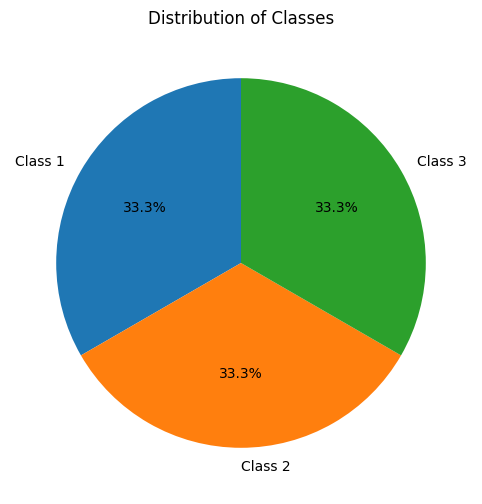

In [ ]:
class_counts=df['Class (1, 2, 3)'].value_counts().sort_index()
plt.figure(figsize=(8,6))
plt.pie(class_counts, labels=["Class 1", "Class 2", "Class 3"],autopct="%1.1f%%",startangle=90)
plt.title("Distribution of Classes")
plt.show()

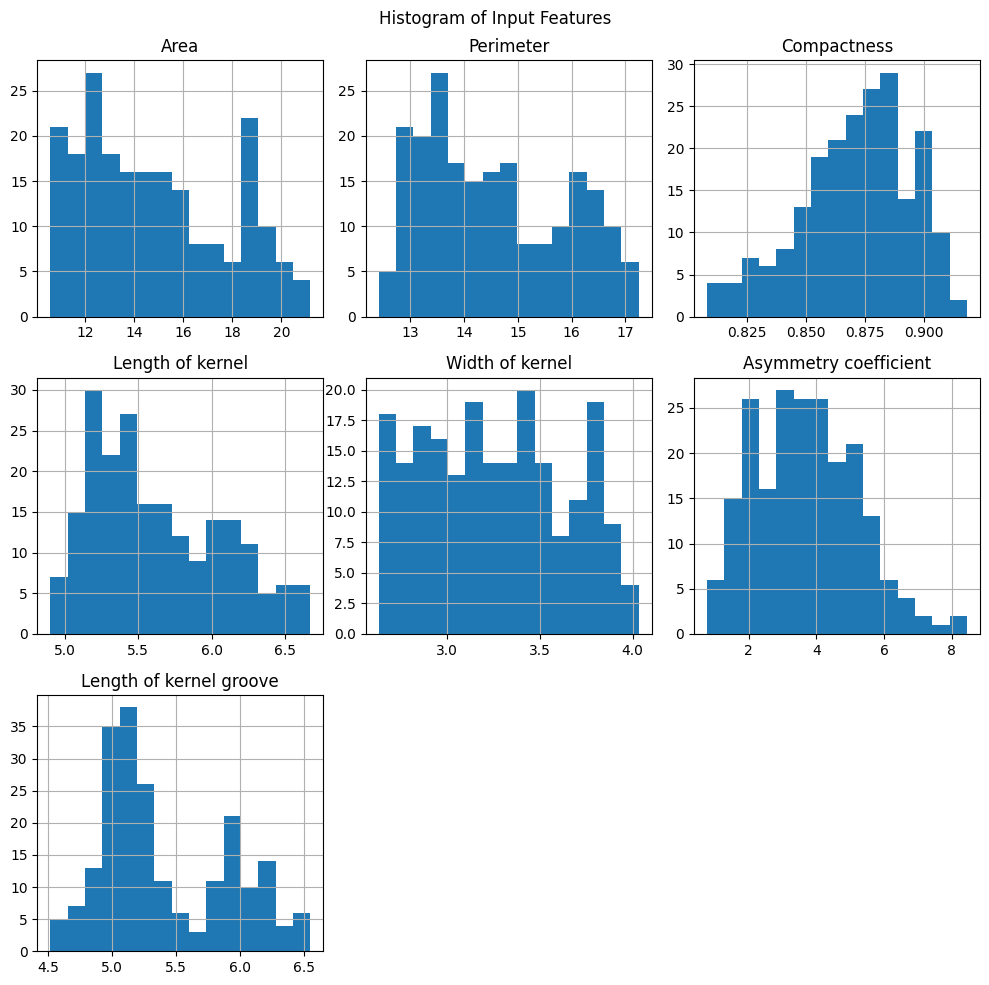

In [ ]:
df.drop("Class (1, 2, 3)",axis=1).hist(figsize=(10,10),bins=15)
plt.suptitle("Histogram of Input Features")
plt.tight_layout()
plt.show()

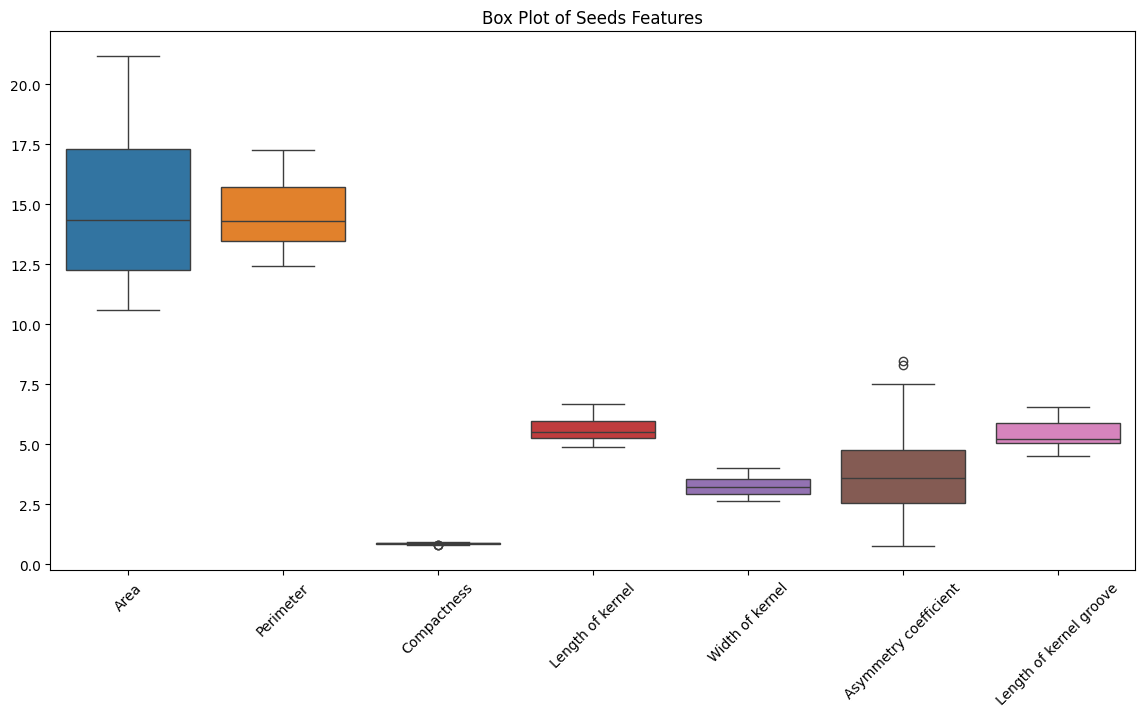

In [ ]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df.drop("Class (1, 2, 3)",axis=1))
plt.title("Box Plot of Seeds Features")
plt.xticks(rotation=45)
plt.show()

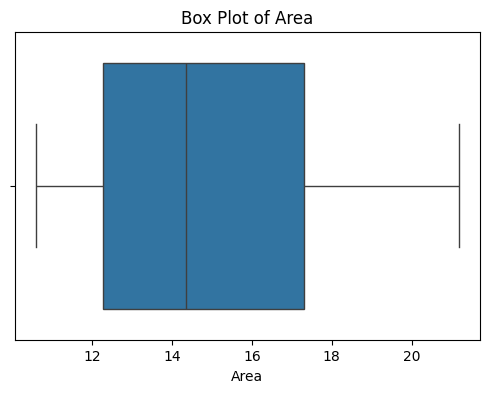

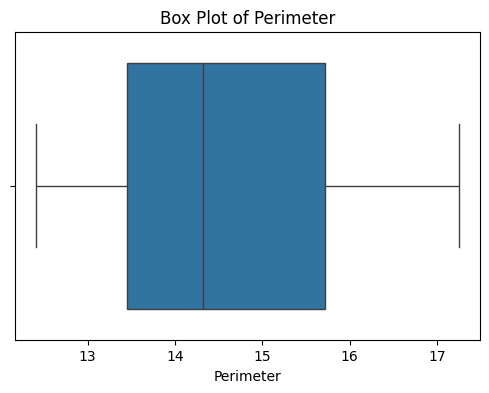

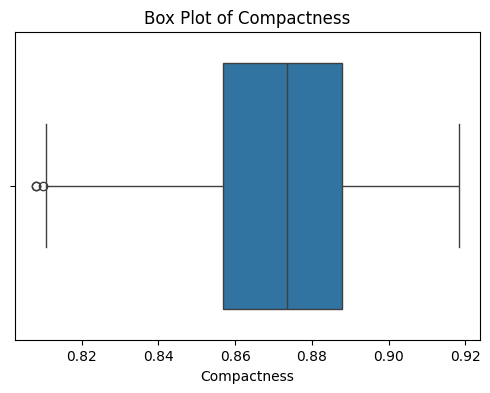

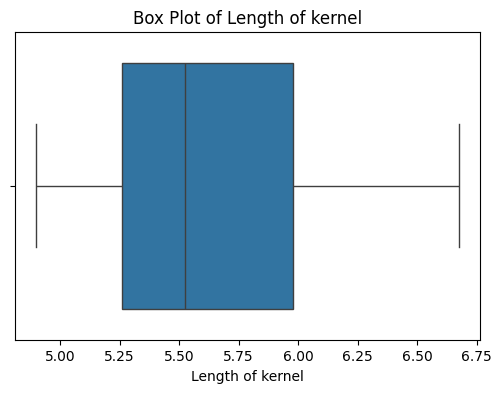

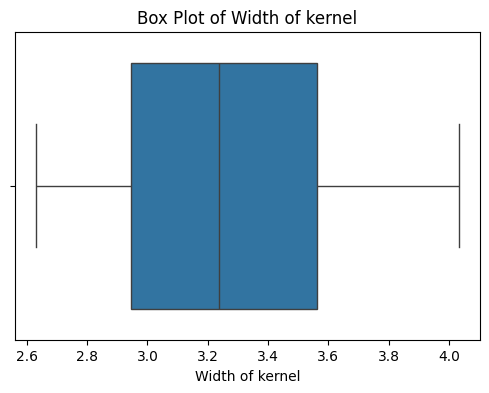

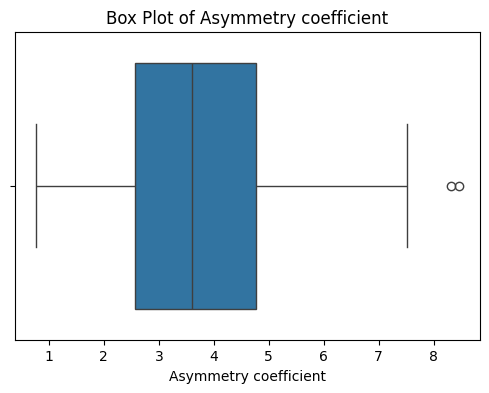

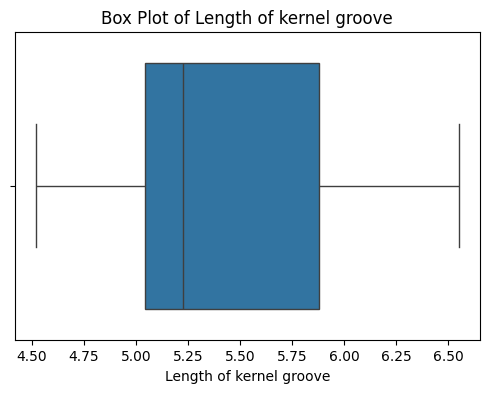

In [ ]:
features=df.drop("Class (1, 2, 3)",axis=1).columns
for feature in features:
  plt.figure(figsize=(6,4))
  sns.boxplot(x=df[feature])
  plt.title(f"Box Plot of {feature}")
  plt.xlabel(feature)
  plt.show()

### **Multivarient Analysis**

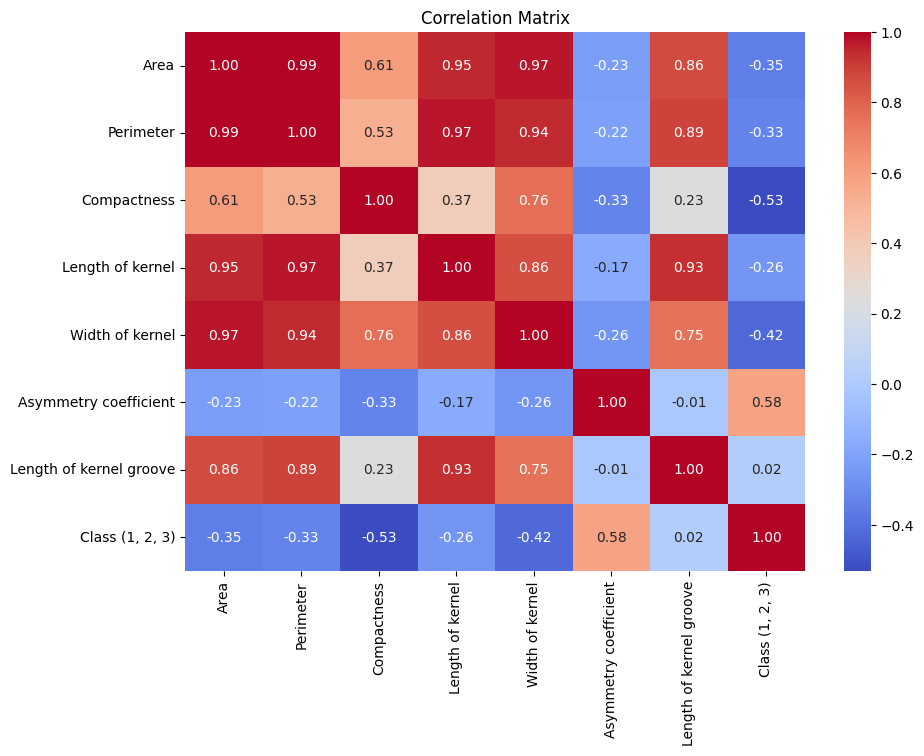

In [ ]:
plt.figure(figsize=(10,7))
correlation=df.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

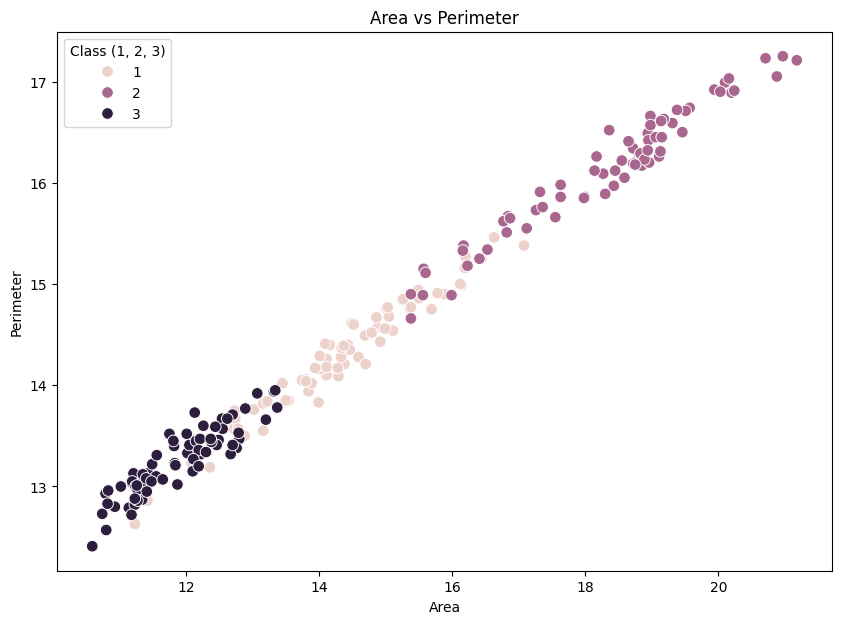

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df,x="Area",y="Perimeter",hue="Class (1, 2, 3)",s=70)
plt.title("Area vs Perimeter")
plt.show()

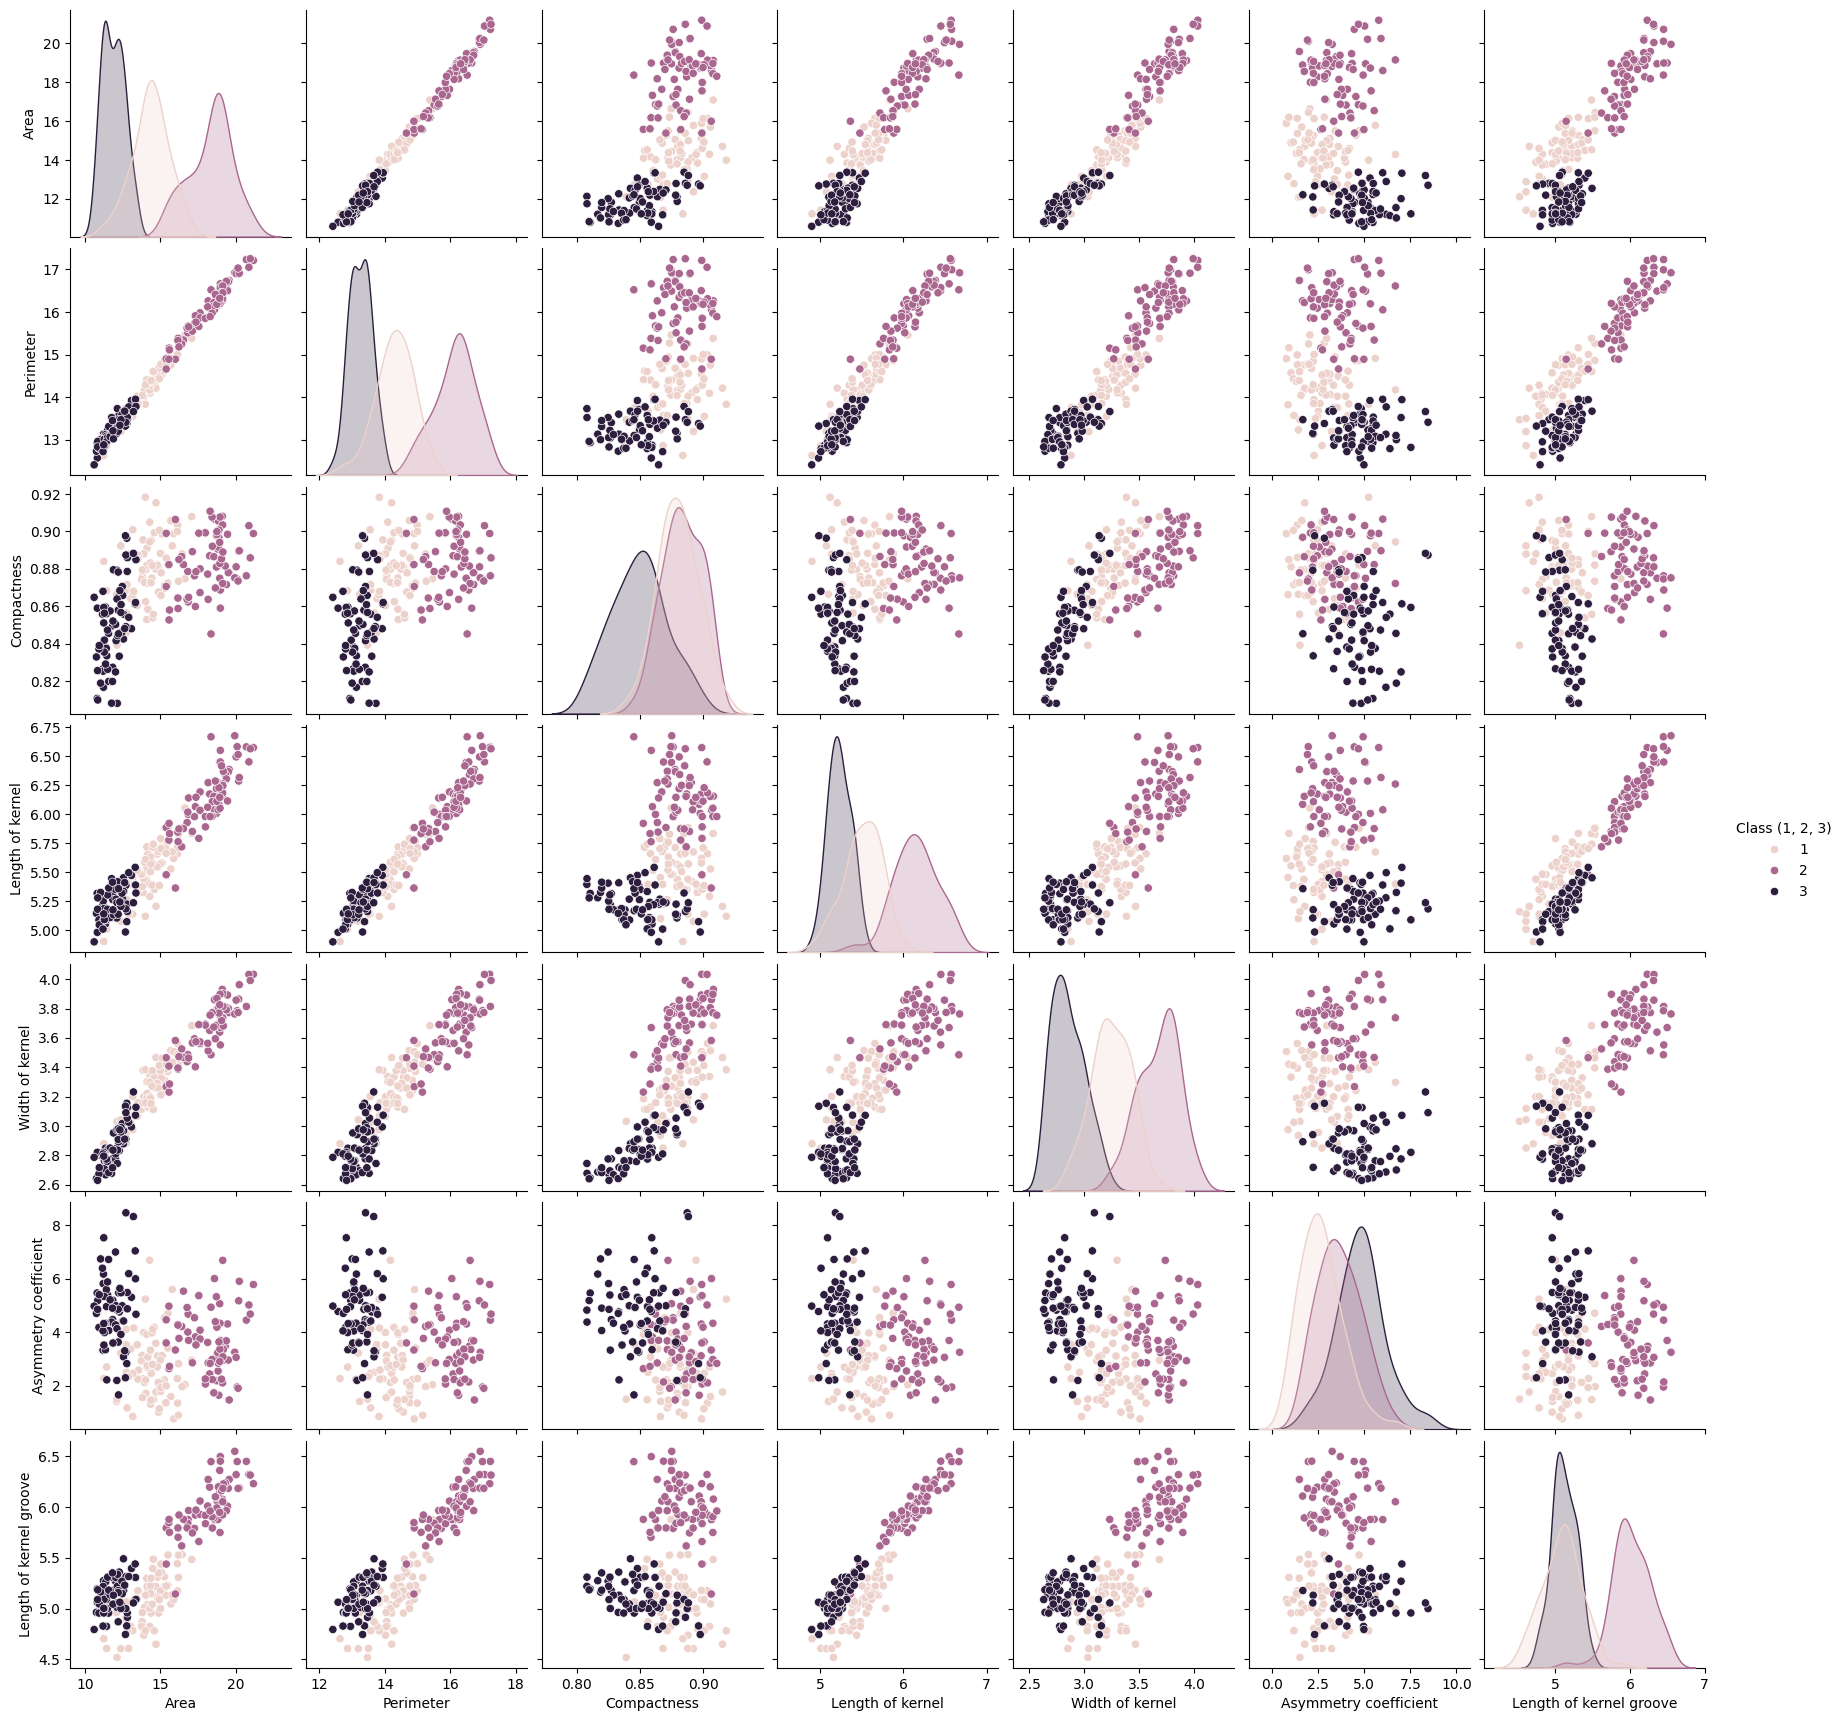

In [ ]:
sns.pairplot(df,hue="Class (1, 2, 3)",diag_kind="kde")
plt.show()

### **Train Test Split**

In [ ]:
X=df.drop("Class (1, 2, 3)",axis=1)
y_original=df["Class (1, 2, 3)"]
print("Input Shape: ",X.shape)
print("Output Shape: ",y_original.shape)

Input Shape:  (210, 7)
Output Shape:  (210,)


In [ ]:
y=y_original-1
print("Original classes: ")
print(sorted(y_original.unique()))
print("\nANN encoded classes: ")
print(sorted(y.unique()))

Original classes: 
[np.int64(1), np.int64(2), np.int64(3)]

ANN encoded classes: 
[np.int64(0), np.int64(1), np.int64(2)]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training samples: ",X_train.shape[0])
print("Testing samples: ",X_test.shape[0])

Training samples:  168
Testing samples:  42


In [ ]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
scaler.fit_transform(X_test)

array([[-0.13481356, -0.30885661,  1.63834475, -0.72108928,  0.28326462,
        -0.76430253, -1.20943602],
       [-0.86696115, -0.79265998, -1.079508  , -0.44412568, -1.01611436,
        -0.08296069, -0.1493714 ],
       [ 0.3031065 ,  0.49244271, -0.70339658,  0.66153059,  0.00779627,
        -0.80711315,  0.9685525 ],
       [-1.32882996, -1.4578896 , -0.42131302, -1.40250766, -1.05769449,
         0.74059948, -0.71763216],
       [ 1.23710786,  1.05184035,  1.89804073,  0.79121989,  1.36954545,
        -0.66416923,  1.14006393],
       [-0.46667485, -0.42224803, -0.31833013, -0.17155833, -0.40280748,
         2.38191499,  0.06140168],
       [ 2.15058173,  2.0799225 ,  0.78313902,  2.07492419,  1.98285233,
         0.67094153,  1.87157051],
       [ 0.37495276,  0.31101645,  1.0697001 ,  0.12079214,  0.53534414,
         1.33559449, -0.56678476],
       [ 1.65107916,  1.67171341,  0.42941519,  1.6418938 ,  1.48908831,
        -0.57346877,  1.60087175],
       [ 1.28842662,  1.2257

In [ ]:
print("First 5 rows of scaled training samples:")
print(X_train_scaled[:5])

First 5 rows of scaled training samples:
[[-1.17682401 -1.1750583  -1.02169157 -1.02785725 -1.35751947  1.43188942
  -0.82441016]
 [-0.87298429 -1.06714618  0.86676795 -1.26492983 -0.59897345 -0.3056117
  -1.63150367]
 [-0.12719589  0.01968295 -0.66917913  0.25096694 -0.40933695 -1.4432301
   0.1615857 ]
 [-1.29421662 -1.37546651 -0.66498255 -1.41310019 -1.26136575  1.7668294
  -0.72886004]
 [-0.58295547 -0.70486981  0.69890488 -0.90020279 -0.09149548  3.02743357
  -0.71462918]]


### **ANN**

In [ ]:
model=Sequential([
    Input(shape=(7,)),
    Dense(16,activation='relu'),
    Dense(8,activation='relu'),
    Dense(3,activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),loss="sparse_categorical_crossentropy",metrics=["accuracy"]
)

In [ ]:
loss="sparse_categorical_crossentropy"

In [ ]:
early_stop=EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)

In [ ]:
history=model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.2090 - loss: 1.1058 - val_accuracy: 0.2941 - val_loss: 1.0670
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4478 - loss: 1.0030 - val_accuracy: 0.4412 - val_loss: 0.9607
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6642 - loss: 0.9112 - val_accuracy: 0.6765 - val_loss: 0.8710
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7910 - loss: 0.8364 - val_accuracy: 0.8235 - val_loss: 0.7889
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8507 - loss: 0.7677 - val_accuracy: 0.9118 - val_loss: 0.7187
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8657 - loss: 0.7094 - val_accuracy: 0.9118 - val_loss: 0.6554
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8881 - loss: 0.6595 - val_accuracy: 0.9118 - val_loss: 0.6026
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8881 - loss: 0.6139 - val_accuracy: 0.9118 - val_loss:

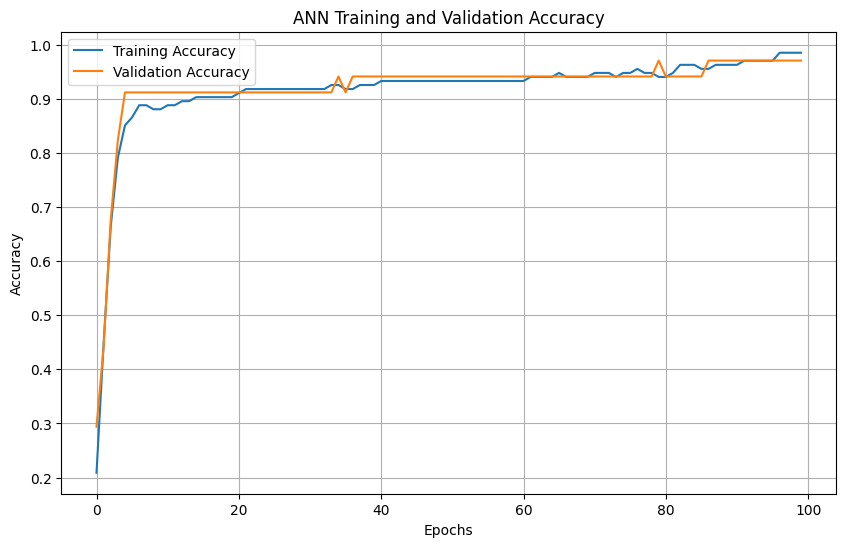

In [ ]:
# Validation Graph
plt.figure(figsize=(10,6))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

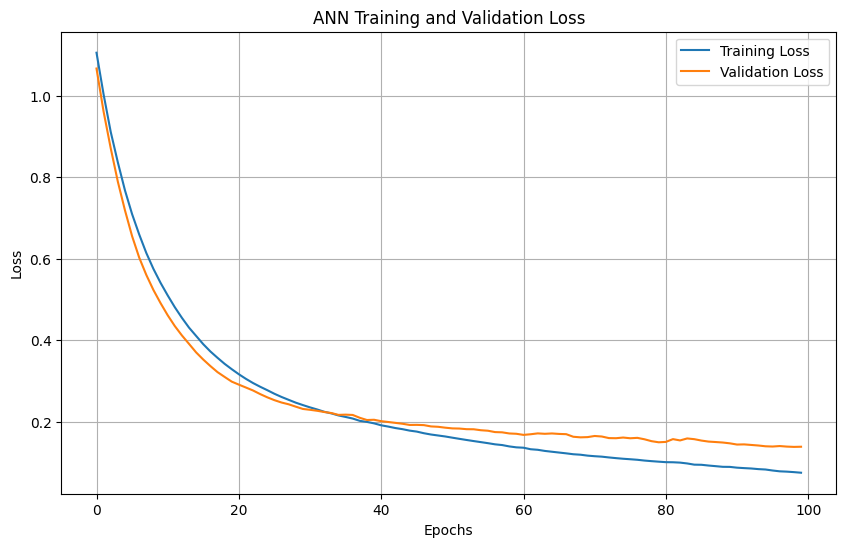

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test,verbose=1)
print("Test loss: ",test_loss)
print("Test accuracy: ",test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8571 - loss: 0.3700
Test loss:  0.3700048625469208
Test accuracy:  0.8571428656578064


In [ ]:
y_prob=model.predict(X_test_scaled,verbose=1)
print(y_prob[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
[[9.83426332e-01 7.63263088e-03 8.94109998e-03]
 [7.86441937e-03 1.29345874e-03 9.90842044e-01]
 [3.80304188e-01 6.05349541e-01 1.43463155e-02]
 [1.29874621e-04 2.06859222e-05 9.99849558e-01]
 [7.84325181e-04 9.99214828e-01 7.77565219e-07]]


In [ ]:
y_pred=np.argmax(y_prob,axis=1)
print("Predicated encoded classes:")
print(y_pred[:10])

Predicated encoded classes:
[0 2 1 2 1 2 1 1 1 1]


In [ ]:
y_pred_original=y_pred+1
y_test_original=y_test+1
print("Predicted classes: ")
print(y_pred_original[:10])

Predicted classes: 
[1 3 2 3 2 3 2 2 2 2]


In [ ]:
comparison=pd.DataFrame({"Actual Class": y_test_original.values, "Predicted Class": y_pred_original})
comparison.head(15)

,Actual Class,Predicted Class
0,1,1
1,3,3
2,2,2
3,3,3
4,2,2
5,3,3
6,2,2
7,1,2
8,2,2
9,2,2


In [ ]:
accuracy=accuracy_score(y_test_original,y_pred_original)
print("Accuracy: ",accuracy)

Accuracy:  0.8571428571428571


In [ ]:
precision=precision_score(y_test_original,y_pred_original, average='weighted')
print("Precision: ",precision)

Precision:  0.8823529411764707


In [ ]:
recall=recall_score(y_test_original,y_pred_original, average='weighted')
print("Recall Score: ",recall)

Recall Score:  0.8571428571428571


In [ ]:
f1=f1_score(y_test_original,y_pred_original, average='weighted')
print("F1 Score: ",f1)

F1 Score:  0.8445747800586509
